# Generating Pokémon Names with RNN and LSTM

In this notebook we will build a **character-level language model** that learns to generate new Pokémon names by studying a list of real ones.

We will compare two sequence models:

- **SimpleRNN** — the classic recurrent network.
- **LSTM** — the more powerful cell with gating.

The idea is simple: the model reads the name **one character at a time** and tries to predict the next character. Once trained, we can ask it to invent brand-new names!

## 1. Why character-level generation?

Pokémon names follow patterns:

- They often end in sounds like *-chu*, *-mon*, *-saur*, *-eon*.
- They mix consonants and vowels in a pronounceable way.
- They rarely have strange character combinations.

A character-level RNN/LSTM is perfect for this: it learns which letters tend to follow which, and captures the *style* of Pokémon naming.

```
 'p' ──▶ 'i' ──▶ 'k' ──▶ 'a' ──▶ 'c' ──▶ 'h' ──▶ 'u' ──▶ <end>
```

At each step the model sees the previous characters and predicts the next one.

## 2. Setup

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


## 3. The dataset: a list of Pokémon names

We use a small, hand-curated list of real Pokémon names from the first few generations. Feel free to extend this list — more data usually gives better generations.

In [2]:
pokemon_names = [
    "bulbasaur", "ivysaur", "venusaur", "charmander", "charmeleon", "charizard",
    "squirtle", "wartortle", "blastoise", "caterpie", "metapod", "butterfree",
    "weedle", "kakuna", "beedrill", "pidgey", "pidgeotto", "pidgeot",
    "rattata", "raticate", "spearow", "fearow", "ekans", "arbok",
    "pikachu", "raichu", "sandshrew", "sandslash", "nidoran", "nidorina",
    "nidoqueen", "nidorino", "nidoking", "clefairy", "clefable", "vulpix",
    "ninetales", "jigglypuff", "wigglytuff", "zubat", "golbat", "oddish",
    "gloom", "vileplume", "paras", "parasect", "venonat", "venomoth",
    "diglett", "dugtrio", "meowth", "persian", "psyduck", "golduck",
    "mankey", "primeape", "growlithe", "arcanine", "poliwag", "poliwhirl",
    "poliwrath", "abra", "kadabra", "alakazam", "machop", "machoke",
    "machamp", "bellsprout", "weepinbell", "victreebel", "tentacool", "tentacruel",
    "geodude", "graveler", "golem", "ponyta", "rapidash", "slowpoke",
    "slowbro", "magnemite", "magneton", "farfetchd", "doduo", "dodrio",
    "seel", "dewgong", "grimer", "muk", "shellder", "cloyster",
    "gastly", "haunter", "gengar", "onix", "drowzee", "hypno",
    "krabby", "kingler", "voltorb", "electrode", "exeggcute", "exeggutor",
    "cubone", "marowak", "hitmonlee", "hitmonchan", "lickitung", "koffing",
    "weezing", "rhyhorn", "rhydon", "chansey", "tangela", "kangaskhan",
    "horsea", "seadra", "goldeen", "seaking", "staryu", "starmie",
    "scyther", "jynx", "electabuzz", "magmar", "pinsir", "tauros",
    "magikarp", "gyarados", "lapras", "ditto", "eevee", "vaporeon",
    "jolteon", "flareon", "porygon", "omanyte", "omastar", "kabuto",
    "kabutops", "aerodactyl", "snorlax", "articuno", "zapdos", "moltres",
    "dratini", "dragonair", "dragonite", "mewtwo", "mew", "chikorita",
    "bayleef", "meganium", "cyndaquil", "quilava", "typhlosion", "totodile",
    "croconaw", "feraligatr", "sentret", "furret", "hoothoot", "noctowl",
    "ledyba", "ledian", "spinarak", "ariados", "crobat", "chinchou",
    "lanturn", "togepi", "togetic", "natu", "xatu", "mareep",
    "flaaffy", "ampharos", "bellossom", "marill", "azumarill", "sudowoodo"
]

print(f"Total names: {len(pokemon_names)}")
print("Some examples:", pokemon_names[:10])

Total names: 180
Some examples: ['bulbasaur', 'ivysaur', 'venusaur', 'charmander', 'charmeleon', 'charizard', 'squirtle', 'wartortle', 'blastoise', 'caterpie']


## 4. Build the character vocabulary

A neural network cannot read letters — it needs numbers. So we:

1. Collect every unique character that appears in our names.
2. Add two special tokens:
   - `^` marks the **start** of a name.
   - `$` marks the **end** of a name.
3. Map each character to an integer (and back).

In [3]:
START, END = "^", "$"

chars = sorted(set("".join(pokemon_names)))
vocab = [START, END] + chars

char_to_idx = {c: i for i, c in enumerate(vocab)}
idx_to_char = {i: c for i, c in enumerate(vocab)}

vocab_size = len(vocab)
print("Vocabulary size:", vocab_size)
print("Vocabulary:", vocab)

Vocabulary size: 28
Vocabulary: ['^', '$', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


## 5. Turn names into training examples

For each name like `"pikachu"` we build the sequence `^pikachu$` and produce `(input, target)` pairs where the target is the **next character**:

| Input    | Target |
|----------|--------|
| `^`      | `p`    |
| `^p`     | `i`    |
| `^pi`    | `k`    |
| `^pik`   | `a`    |
| ...      | ...    |
| `^pikachu` | `$`  |

We pad all inputs to the same length so Keras can batch them.

In [4]:
max_len = max(len(n) for n in pokemon_names) + 1   # +1 for the start token
print("Max sequence length:", max_len)

X, y = [], []
for name in pokemon_names:
    seq = START + name + END
    for i in range(1, len(seq)):
        input_part  = seq[:i]                 # everything up to position i
        target_char = seq[i]                  # the character to predict
        # encode input as integers, left-padded with 0 (we'll mask it)
        encoded = [char_to_idx[c] for c in input_part]
        padded  = [0] * (max_len - len(encoded)) + encoded
        X.append(padded)
        y.append(char_to_idx[target_char])

X = np.array(X, dtype=np.int32)
y = np.array(y, dtype=np.int32)

print("X shape:", X.shape)   # (examples, max_len)
print("y shape:", y.shape)   # (examples,)
print("\nOne example input (as ids):", X[5])
print("Decoded input:", "".join(idx_to_char[i] for i in X[5] if i != 0))
print("Target:", idx_to_char[y[5]])

Max sequence length: 11
X shape: (1492, 11)
y shape: (1492,)

One example input (as ids): [ 0  0  0  0  0  0  3 22 13  3  2]
Decoded input: bulba
Target: s


## 6. A SimpleRNN language model

**Recipe:**
1. `Embedding` turns each character id into a small dense vector the network can work with.
2. `SimpleRNN` reads the sequence and keeps a hidden state.
3. `Dense(vocab_size, softmax)` outputs a probability distribution over the next character.

In [5]:
embed_dim = 16
hidden_units = 64

rnn_model = keras.Sequential([
    keras.Input(shape=(max_len,)),
    layers.Embedding(input_dim=vocab_size, output_dim=embed_dim, mask_zero=True),
    layers.SimpleRNN(hidden_units, activation='tanh'),
    layers.Dense(vocab_size, activation='softmax')
])

rnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 11, 16)         │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         5,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 28)             │         1,820 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,452 (29.11 KB)

 Trainable params: 7,452 (29.11 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history_rnn = rnn_model.fit(
    X, y,
    epochs=40,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/40
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.1207 - loss: 3.2280 - val_accuracy: 0.1533 - val_loss: 3.0705
Epoch 2/40
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1498 - loss: 3.0073 - val_accuracy: 0.1733 - val_loss: 2.9865
Epoch 3/40
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1692 - loss: 2.9324 - val_accuracy: 0.1800 - val_loss: 2.9552
Epoch 4/40
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1811 - loss: 2.8912 - val_accuracy: 0.1667 - val_loss: 2.9226
Epoch 5/40
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1908 - loss: 2.8539 - val_accuracy: 0.1800 - val_loss: 2.8895
Epoch 6/40
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2049 - loss: 2.8166 - val_accuracy: 0.2133 - val_loss: 2.8600
Epoch 7/40
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2086 - loss: 2.7758 - val_accuracy: 0.2200 - val_loss: 2.8344
Epoch 8/40
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2288 - loss: 2.7310 - val_accuracy: 0.2400 - val_los

## 7. A name-sampling function

To generate a name we:

1. Start with just the start token `^`.
2. Ask the model for the probability of each possible next character.
3. Sample one according to that probability (with a **temperature** to control creativity).
4. Append it and repeat until we hit the end token `$` (or reach the max length).

**Temperature** tip:
- Low temperature (e.g. 0.2) → safe, repetitive names.
- High temperature (e.g. 1.2) → creative, sometimes nonsense names.
- Around 0.7–1.0 is usually the sweet spot.

In [7]:
def sample_name(model, temperature=0.8, max_length=max_len):
    """Generate one Pokémon name from a trained model."""
    generated = START
    for _ in range(max_length):
        encoded = [char_to_idx[c] for c in generated]
        padded  = [0] * (max_len - len(encoded)) + encoded
        padded  = np.array(padded, dtype=np.int32)[None, :]    # add batch dim

        probs = model.predict(padded, verbose=0)[0]

        # apply temperature
        probs = np.log(probs + 1e-9) / temperature
        probs = np.exp(probs) / np.sum(np.exp(probs))

        next_idx = np.random.choice(len(probs), p=probs)
        next_char = idx_to_char[next_idx]

        if next_char == END:
            break
        generated += next_char

    return generated[1:]   # drop the start token

print("Names generated by the SimpleRNN:\n")
for _ in range(10):
    print(" -", sample_name(rnn_model, temperature=0.8))

Names generated by the SimpleRNN:

 - iwjlagbol
 - ^ytaffsie
 - odigel
 - macmadste
 - bhedocun
 - gilewotten
 - daking
 - feasey
 - darsit
 - harmachat


## 8. Now the LSTM version

We keep everything the same and only swap the recurrent layer. LSTMs handle the longer-range dependencies in names (e.g. consistent word endings) better than SimpleRNNs.

In [8]:
lstm_model = keras.Sequential([
    keras.Input(shape=(max_len,)),
    layers.Embedding(input_dim=vocab_size, output_dim=embed_dim, mask_zero=True),
    layers.LSTM(hidden_units),    # <-- the only change!
    layers.Dense(vocab_size, activation='softmax')
])

lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 11, 16)         │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        20,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 28)             │         1,820 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,004 (89.86 KB)

 Trainable params: 23,004 (89.86 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history_lstm = lstm_model.fit(
    X, y,
    epochs=40,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/40
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.1148 - loss: 3.3110 - val_accuracy: 0.1333 - val_loss: 3.2676
Epoch 2/40
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1207 - loss: 3.1328 - val_accuracy: 0.1333 - val_loss: 3.0122
Epoch 3/40
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1244 - loss: 2.9880 - val_accuracy: 0.1333 - val_loss: 2.9986
Epoch 4/40
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.1401 - loss: 2.9548 - val_accuracy: 0.1800 - val_loss: 2.9697
Epoch 5/40
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.1654 - loss: 2.9316 - val_accuracy: 0.1933 - val_loss: 2.9463
Epoch 6/40
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.1766 - loss: 2.9128 - val_accuracy: 0.2200 - val_loss: 2.9316
Epoch 7/40
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.1818 - loss: 2.8972 - val_accuracy: 0.2200 - val_loss: 2.9184
Epoch 8/40
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.1826 - loss: 2.8832 - val_accuracy: 0.2333 - v

In [10]:
print("Names generated by the LSTM:\n")
for _ in range(10):
    print(" -", sample_name(lstm_model, temperature=0.8))

Names generated by the LSTM:

 - vedrorod
 - jadareer
 - jogalath
 - vlatpote
 - eirobha
 - bawinomrl
 - lbabtobau
 - cizarokh
 - oonata
 - 


## 9. Explore different temperatures

Let's see how the LSTM behaves as we dial creativity up and down.

In [11]:
for temp in [0.3, 0.7, 1.0, 1.3]:
    print(f"\n--- temperature = {temp} ---")
    for _ in range(5):
        print(" -", sample_name(lstm_model, temperature=temp))


--- temperature = 0.3 ---
 - nictane
 - hodigot
 - orina
 - urimath
 - radita

--- temperature = 0.7 ---
 - be
 - ckarere
 - risshan
 - exesponi
 - dogasatpe

--- temperature = 1.0 ---
 - ^xhyyulfre
 - nuricny
 - mororaendel
 - merorroa
 - aobinan

--- temperature = 1.3 ---
 - 
 - uidlogl
 - 
 - meorylar
 - kaaxtim


## 10. Compare RNN vs LSTM losses

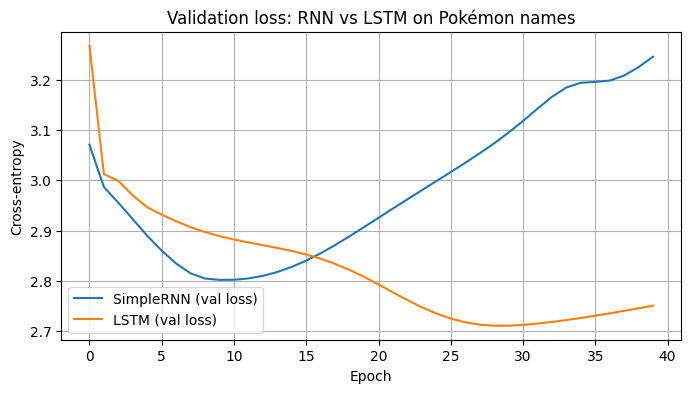

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(history_rnn.history['val_loss'],  label='SimpleRNN (val loss)')
plt.plot(history_lstm.history['val_loss'], label='LSTM (val loss)')
plt.xlabel('Epoch')
plt.ylabel('Cross-entropy')
plt.title('Validation loss: RNN vs LSTM on Pokémon names')
plt.legend()
plt.grid(True)
plt.show()

## 11. Filter out names that already exist

A good generative model shouldn't just memorize, it should *invent* new names. Let's pull some samples and keep only those that are not already in the training list.

In [13]:
known = set(pokemon_names)
new_names = []

while len(new_names) < 15:
    candidate = sample_name(lstm_model, temperature=0.9)
    if candidate and candidate not in known and candidate not in new_names:
        new_names.append(candidate)

print("Brand-new Pokémon names invented by our LSTM:\n")
for n in new_names:
    print(" -", n.capitalize())

Brand-new Pokémon names invented by our LSTM:

 - Cenorgsin
 - Jchobb
 - Vincplegdee
 - Iomora
 - Panunele
 - Xgutece
 - Arako
 - Tadpotita
 - Sqymarese
 - Sodter
 - We
 - Wakuvel
 - Georro
 - Laniteaer
 - Baraso


##  Your assignment, optimize this notebook for a different domain


Have fun and remember: the coolest generative models come from **interesting datasets**, not just bigger networks.